In [1]:
!pip install squidpy scanpy anndata seaborn igraph leidenalg -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
import squidpy as sq

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

squidpy==1.8.1


In [3]:
np.random.seed(42)

n_cells = 8000
n_genes  = 100
n_cell_types = 5

# --- Assign each cell to one of 5 simulated cell populations ---
cell_type_labels = np.random.choice(n_cell_types, size=n_cells)

# --- Simulate spatial coordinates with population-level clustering ---
# Each population has its own Gaussian center on the tissue
centers = np.array([
    [2000, 2000],
    [8000, 2000],
    [5000, 5000],
    [2000, 8000],
    [8000, 8000],
], dtype=float)

spatial_coords = np.zeros((n_cells, 2))
for ct in range(n_cell_types):
    mask = cell_type_labels == ct
    n = mask.sum()
    spatial_coords[mask] = centers[ct] + np.random.randn(n, 2) * 1500

# Clip to tissue bounds
spatial_coords = np.clip(spatial_coords, 0, 10000)

# --- Simulate gene expression (Negative Binomial) ---
# Each cell type has a distinct expression profile for the first 20 genes
X = np.random.negative_binomial(2, 0.4, size=(n_cells, n_genes)).astype(float)
for ct in range(n_cell_types):
    mask = cell_type_labels == ct
    gene_start = ct * (n_genes // n_cell_types)
    gene_end   = gene_start + (n_genes // n_cell_types)
    # Upregulate marker genes for this cell type
    X[np.ix_(mask, np.arange(gene_start, gene_end))] += np.random.negative_binomial(
        10, 0.3, size=(mask.sum(), gene_end - gene_start)
    )

# --- Build obs metadata matching real Xenium columns ---
cell_ids = [f"cell_{i:06d}" for i in range(n_cells)]

cell_area    = np.random.uniform(50, 300, n_cells)
nucleus_area = cell_area * np.random.uniform(0.2, 0.6, n_cells)
total_counts = X.sum(axis=1)

obs_df = pd.DataFrame({
    "cell_id":                    cell_ids,
    "transcript_counts":          total_counts.astype(int),
    "control_probe_counts":       np.random.binomial(1, 0.0001, n_cells),
    "control_codeword_counts":    np.random.binomial(1, 0.00005, n_cells),
    "unassigned_codeword_counts": np.random.randint(0, 3, n_cells),
    "deprecated_codeword_counts": np.zeros(n_cells, dtype=int),
    "total_counts":               total_counts.astype(int),
    "cell_area":                  cell_area,
    "nucleus_area":               nucleus_area,
    "region":                     ["cell_circles"] * n_cells,
    "z_level":                    np.random.choice([4.0, 5.0, 6.0, 7.0], n_cells),
    "nucleus_count":              np.ones(n_cells, dtype=int),
    "cell_labels":                np.arange(1, n_cells + 1),
}, index=cell_ids)

# --- Gene names matching real Xenium panel style ---
gene_names = (
    ["EPCAM", "KRT7", "KRT19", "KRT8", "MUC1",
     "CDH1", "CLDN4", "CLDN7", "TFF1", "TFF3",
     "AREG", "MET", "ANXA1", "DMBT1", "IGKC",
     "IGHG1", "IDO1", "SPARC", "APOE", "FABP4"]
    + [f"GENE_{i:03d}" for i in range(n_genes - 20)]
)

var_df = pd.DataFrame({
    "gene_ids":     gene_names,
    "feature_types": ["Gene Expression"] * n_genes,
    "genome":        ["GRCh38"] * n_genes,
}, index=gene_names)

# --- Assemble AnnData ---
adata = ad.AnnData(X=X, obs=obs_df, var=var_df)
adata.obsm["spatial"] = spatial_coords

print("Synthetic Xenium-like AnnData:")
print(adata)
print(f"\nCells: {adata.n_obs} | Genes: {adata.n_vars}")
print(f"Spatial coords shape: {adata.obsm['spatial'].shape}")

Synthetic Xenium-like AnnData:
AnnData object with n_obs × n_vars = 8000 × 100
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

Cells: 8000 | Genes: 100
Spatial coords shape: (8000, 2)


In [5]:
# Preview spatial coordinates
print("Spatial coordinates (first 5 cells):")
print(adata.obsm["spatial"][:5])

Spatial coordinates (first 5 cells):
[[2644.57141837 7709.82191412]
 [9296.04111197 7120.29298568]
 [6021.45463542 5304.59203234]
 [7736.36304517 9169.56286398]
 [7505.01946878 7333.68593889]]


In [6]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50), inplace=True)

# Control probe percentage (should be near 0% in real data)
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count %  : {cprobes:.5f}%")
print(f"Negative decoding count %   : {cwords:.5f}%")
print("(Both should be near 0% — confirms high data quality)")

Negative DNA probe count %  : 0.00003%
Negative decoding count %   : 0.00000%
(Both should be near 0% — confirms high data quality)


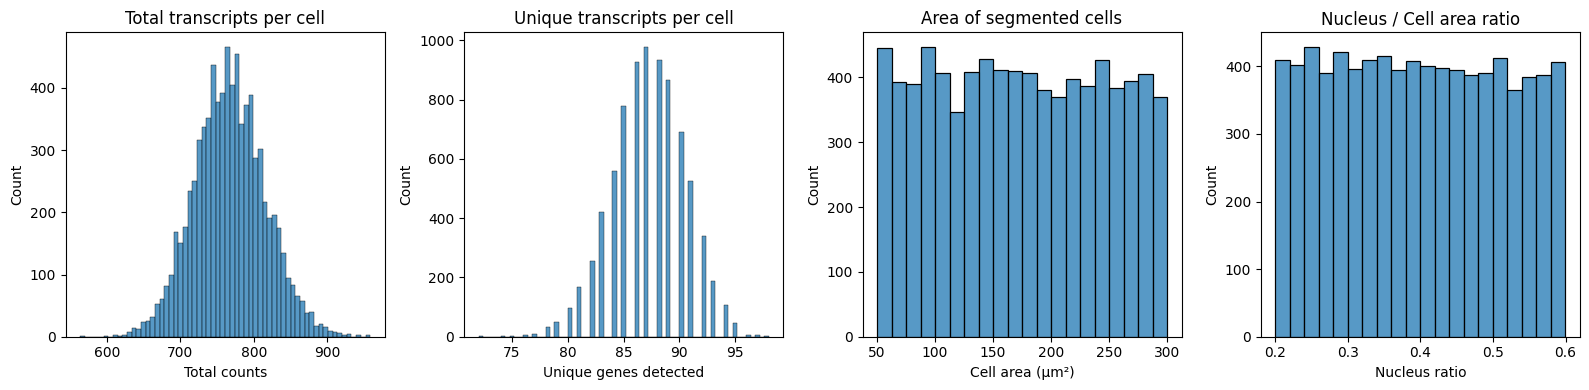

Saved: xenium_qc_distributions.png


In [7]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
axs[0].set_xlabel("Total counts")

axs[1].set_title("Unique transcripts per cell")
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1])
axs[1].set_xlabel("Unique genes detected")

axs[2].set_title("Area of segmented cells")
sns.histplot(adata.obs["cell_area"], kde=False, ax=axs[2])
axs[2].set_xlabel("Cell area (µm²)")

axs[3].set_title("Nucleus / Cell area ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False, ax=axs[3]
)
axs[3].set_xlabel("Nucleus ratio")

plt.tight_layout()
plt.savefig("xenium_qc_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_qc_distributions.png")

In [8]:
print(f"Before filtering: {adata.n_obs} cells, {adata.n_vars} genes")

sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

print(f"After filtering:  {adata.n_obs} cells, {adata.n_vars} genes")

Before filtering: 8000 cells, 100 genes
After filtering:  8000 cells, 100 genes


In [9]:
# Save raw counts before normalization
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, directed=False)

print(f"Leiden clusters found: {adata.obs['leiden'].nunique()}")
print("Cluster sizes:")
print(adata.obs["leiden"].value_counts().sort_index())

Leiden clusters found: 5
Cluster sizes:
leiden
0    1603
1    1624
2    1557
3    1625
4    1591
Name: count, dtype: int64


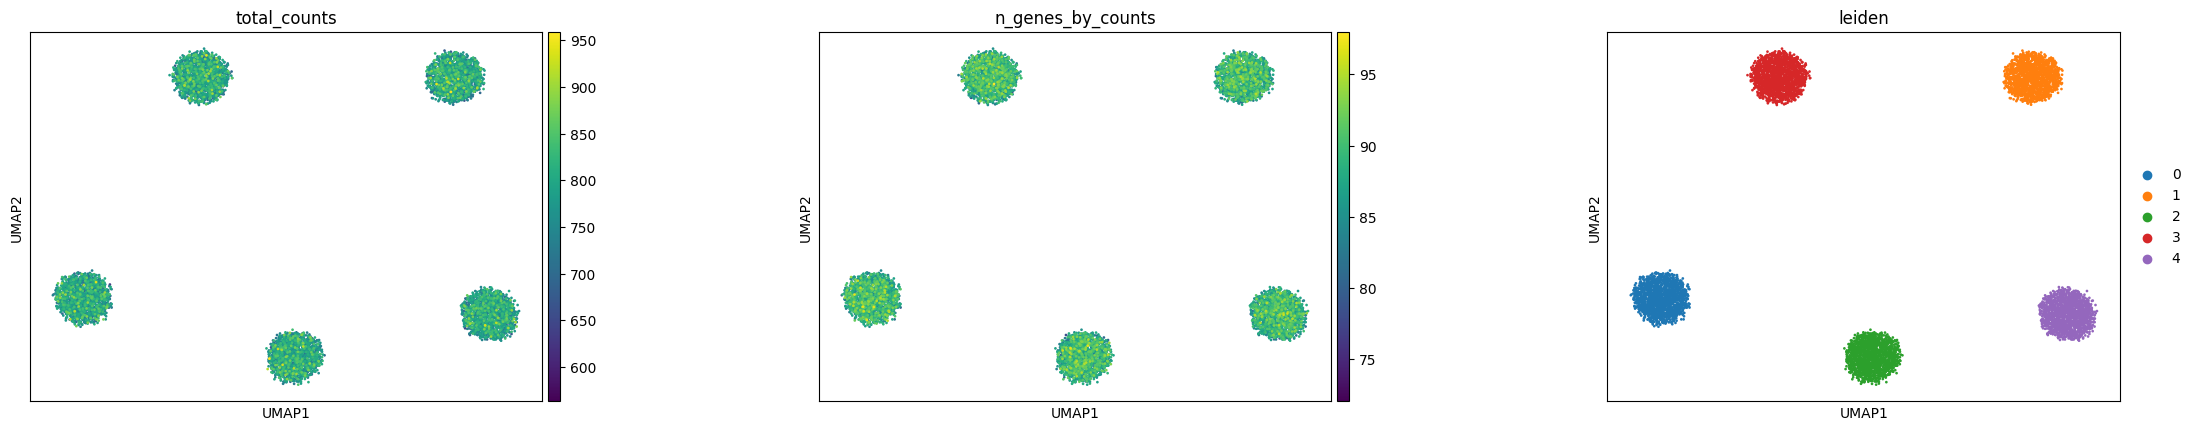

Saved: xenium_umap.png


In [10]:
sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden"],
    wspace=0.4,
    show=False,
)
plt.savefig("xenium_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_umap.png")

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


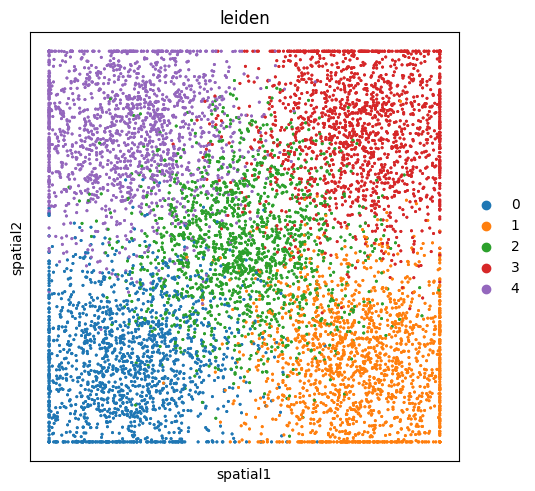

Saved: xenium_spatial_leiden.png


In [11]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=["leiden"],
    wspace=0.4,
    size=5,
)
plt.savefig("xenium_spatial_leiden.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_spatial_leiden.png")

In [12]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
print(f"Spatial graph built. Connectivity matrix: {adata.obsp['spatial_connectivities'].shape}")

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Spatial graph built. Connectivity matrix: (8000, 8000)


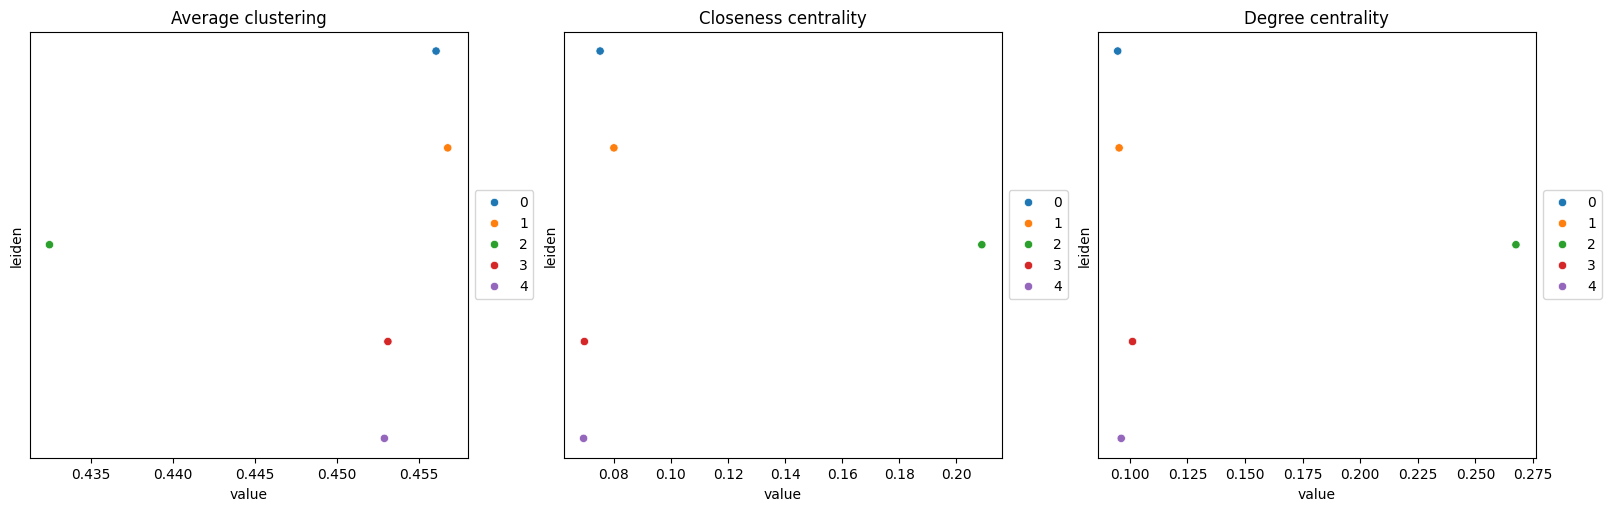

Saved: xenium_centrality_scores.png


In [13]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))
plt.savefig("xenium_centrality_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_centrality_scores.png")

In [14]:
# Create 50% subsample for faster co-occurrence computation
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)
print(f"Subsample size: {adata_subsample.n_obs} cells")

Subsample size: 4000 cells


Showing co-occurrence for cluster: 0


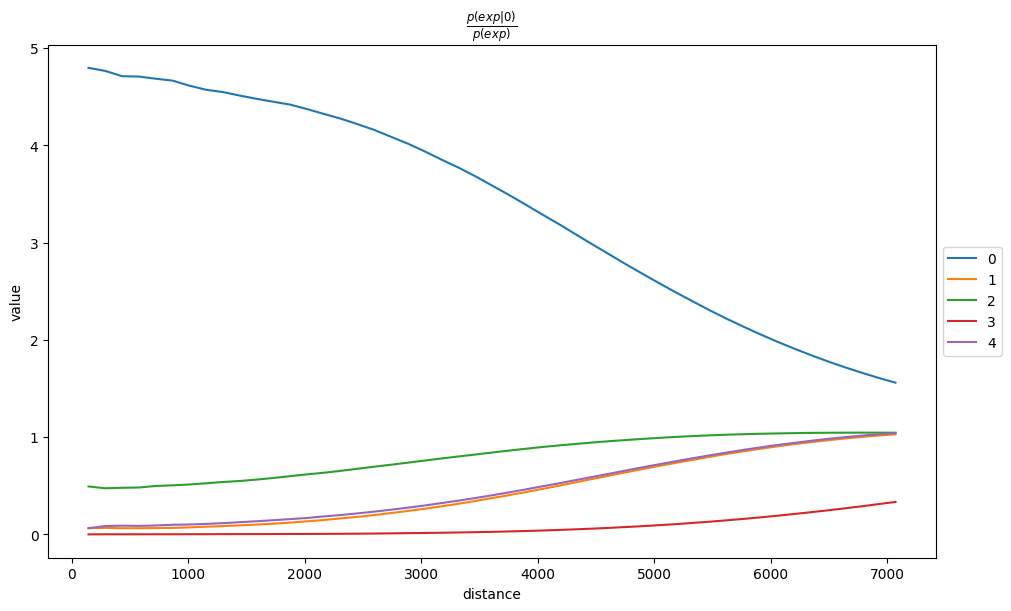

Saved: xenium_co_occurrence.png


In [15]:
sq.gr.co_occurrence(adata_subsample, cluster_key="leiden")

# Pick the first cluster to visualize
first_cluster = adata_subsample.obs["leiden"].cat.categories[0]
print(f"Showing co-occurrence for cluster: {first_cluster}")

sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters=first_cluster,
    figsize=(10, 6),
)
plt.savefig("xenium_co_occurrence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_co_occurrence.png")

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


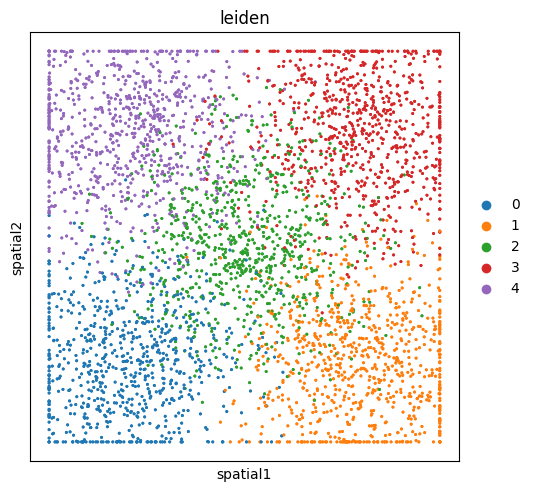

Saved: xenium_subsample_spatial.png


In [16]:
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=5,
)
plt.savefig("xenium_subsample_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_subsample_spatial.png")

  0%|          | 0/1000 [00:00<?, ?/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


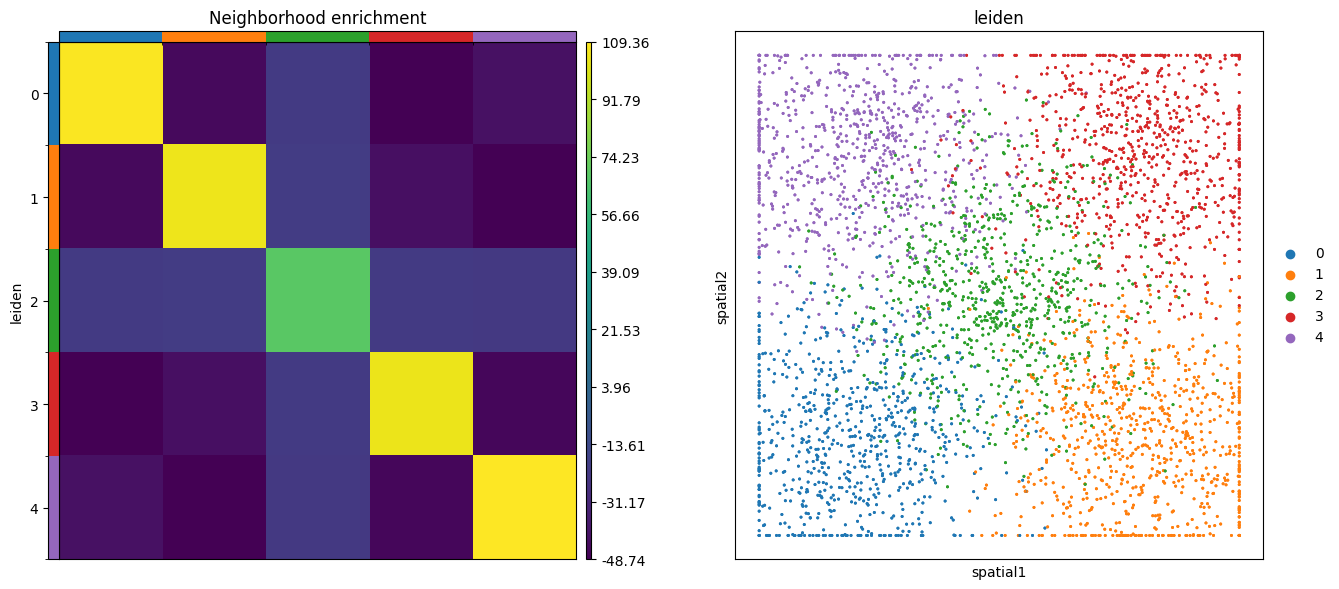

Saved: xenium_nhood_enrichment.png


In [17]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    title="Neighborhood enrichment",
    ax=ax[0],
)

sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=5,
    ax=ax[1],
)

plt.tight_layout()
plt.savefig("xenium_nhood_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_nhood_enrichment.png")

In [18]:
# Rebuild spatial graph on subsample
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)

# Compute Moran's I for all genes
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

print("Top 10 spatially variable genes (Moran's I):")
print(adata_subsample.uns["moranI"].head(10))

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

Top 10 spatially variable genes (Moran's I):
                 I  pval_norm  var_norm  pval_z_sim  pval_sim   var_sim  \
GENE_060  0.537252        0.0  0.000092         0.0  0.009901  0.000156   
GENE_006  0.533557        0.0  0.000092         0.0  0.009901  0.000172   
GENE_010  0.531287        0.0  0.000092         0.0  0.009901  0.000159   
GENE_067  0.530664        0.0  0.000092         0.0  0.009901  0.000150   
GENE_054  0.530037        0.0  0.000092         0.0  0.009901  0.000141   
GENE_002  0.527408        0.0  0.000092         0.0  0.009901  0.000134   
GENE_019  0.527145        0.0  0.000092         0.0  0.009901  0.000153   
GENE_071  0.526459        0.0  0.000092         0.0  0.009901  0.000139   
GENE_011  0.525509        0.0  0.000092         0.0  0.009901  0.000187   
GENE_075  0.524438        0.0  0.000092         0.0  0.009901  0.000148   

          pval_norm_fdr_bh  pval_z_sim_fdr_bh  pval_sim_fdr_bh  
GENE_060               0.0                0.0         0.009901  

Top spatially variable genes: ['GENE_060', 'GENE_006']


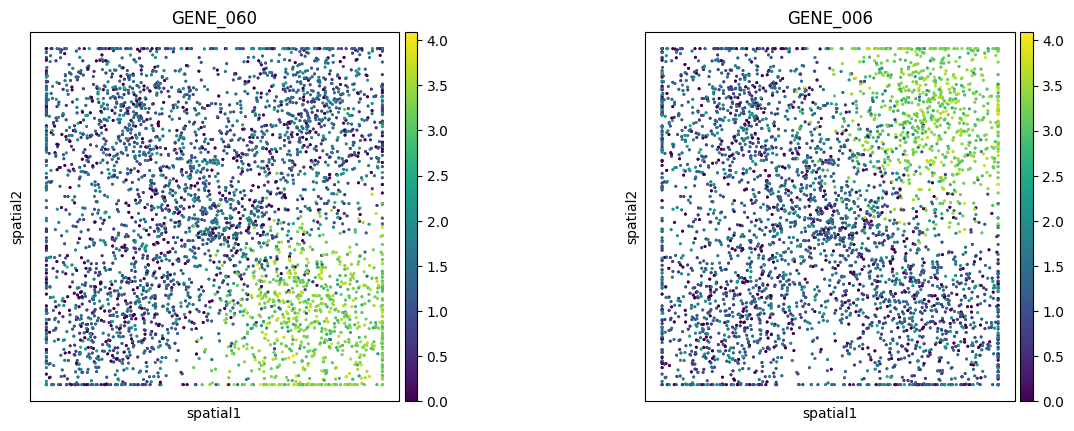

Saved: xenium_spatially_variable_genes.png


In [19]:
top_genes = adata_subsample.uns["moranI"].head(2).index.tolist()
print(f"Top spatially variable genes: {top_genes}")

sq.pl.spatial_scatter(
    adata_subsample,
    color=top_genes,
    shape=None,
    size=5,
    img=False,
)
plt.savefig("xenium_spatially_variable_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xenium_spatially_variable_genes.png")